# Datenbereinigung und einfache Analyseaufgaben

Dieses Notebook stellt ein kleines Projekt dar, in welchem ich einen [Abrechnungs-/Verwaltungsdatensatz](https://github.com/EikeSuemper/Meine-Lernreise-Aktuariat-QuantFinance/blob/main/04_Datens%C3%A4tze/claims_data.csv) bereinige, fehlende Daten ersetze, schätze und verschiedene Funktionen anwende. Es dient der Veranschaulichung der gelernten Fähigkeiten aus dem [Grundlagenordner](https://github.com/EikeSuemper/Meine-Lernreise-Aktuariat-QuantFinance/tree/main/01_Grundlagen).

#### 🧹 Aufgabe 1: Data Cleaning
 
- policy_type → fehlend → `auto`
- customer_segment → fehlend → `unknown`
- premium → Median
- claim_amount → Median
- claim_frequency → Mean
- processing_time → Mean 
- risk_score → Mean 

Ergebnisse auf 2 Dezimalstellen runden

#### 📊 Aufgabe 2: Portfolio Analyse

Gruppiere nach policy_type und berechne:
- avg_premium
- avg_claim_amount
- avg_risk_score
- avg_claim_frequency

Ergebnisse auf 2 Dezimalstellen runden

## Notewendige Bibliotheken und Datensatz laden
Zuerst lade ich die notwendigen Bibliotheken, anschließend mache ich mir einen Überblick über den Datensatz. Dabei nutze ich die `.info()` Funktion und lasse die Fehleranzahl visualisieren.

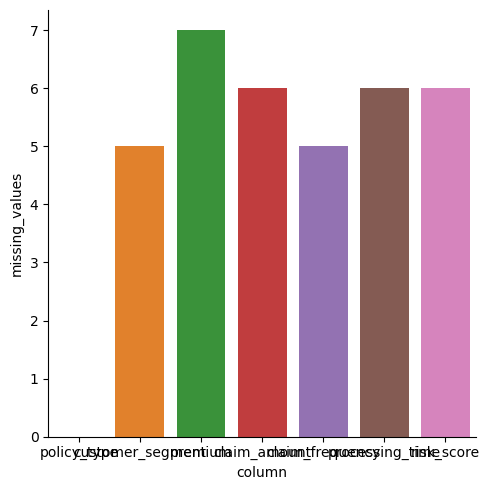

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("https://raw.githubusercontent.com/EikeSuemper/Meine-Lernreise-Aktuariat-QuantFinance/main/04_Datens%C3%A4tze/claims_data.csv")

# Fehlende Werte je Kategorie mittels eines Säulendiagrammes darstellen
FD = df.isna().sum().reset_index()
FD.columns = ["column", "missing_values"]
sns.catplot(data = FD, x="column", y="missing_values", kind="bar", hue = "column")

Das Säulendiagramm zeigt uns, dass fehlende Daten vorliegen.

## 🧹 Aufgabe 1: Data Cleaning

Zuerst kopiere ich den Datensatz und speiere diesen als clean_data ab. Im Anschluss bereinige ich kategorischen Werte nach Vorgabe.

In [60]:
clean_data = df.copy()      # Datensatz neu abgespeichert

clean_data["policy_type"] = clean_data["policy_type"].fillna("auto")
clean_data["customer_segment"] = clean_data["customer_segment"].fillna("unknown")
clean_data
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   policy_type       80 non-null     object 
 1   customer_segment  80 non-null     object 
 2   premium           73 non-null     float64
 3   claim_amount      74 non-null     float64
 4   claim_frequency   75 non-null     float64
 5   processing_time   74 non-null     float64
 6   risk_score        74 non-null     float64
dtypes: float64(5), object(2)
memory usage: 4.5+ KB


Somit wurden in den bearbeiteten Spalten alle fehlenden Werte entfernt/bearbeitet. Nun zu den numerischen Werten: Offensichtlich existieren in diesen Spalten fehlende Werte. Diese gilt es durch den Durchschnitt zu ersetzen. Für die Spalten "Premium" und "claim_amount" soll der Median angewendet werden:

In [61]:
# Fehlende Werte mit dem Durchschnitt ersetzen
clean_data["claim_frequency"] = clean_data["claim_frequency"].fillna(round(clean_data["claim_frequency"].mean(), 2))
clean_data["processing_time"] = clean_data["processing_time"].fillna(round(clean_data["processing_time"].mean(), 2))
clean_data["risk_score"] = clean_data["risk_score"].fillna(round(clean_data["risk_score"].mean(), 2))

# Median für die fehlenden Werte anwenden
clean_data["premium"] = clean_data["premium"].fillna(clean_data["premium"].median())
clean_data["claim_amount"] = clean_data["claim_amount"].fillna(clean_data["claim_amount"].median())

clean_data.info()
clean_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   policy_type       80 non-null     object 
 1   customer_segment  80 non-null     object 
 2   premium           80 non-null     float64
 3   claim_amount      80 non-null     float64
 4   claim_frequency   80 non-null     float64
 5   processing_time   80 non-null     float64
 6   risk_score        80 non-null     float64
dtypes: float64(5), object(2)
memory usage: 4.5+ KB


,policy_type,customer_segment,premium,claim_amount,claim_frequency,processing_time,risk_score
0,auto,retail,1200.0,5000.0,1.0,45.00,7.5
1,home,corporate,2500.0,12000.0,2.0,60.00,8.2
2,life,retail,1800.0,6500.0,1.0,55.00,7.9
3,auto,unknown,1500.0,3000.0,1.0,51.23,6.8
4,health,retail,1820.0,2000.0,3.0,40.00,7.2


Nun liegen keine fehlenden Daten mehr vor.

## 📊 Aufgabe 2: Portfolio Analyse

In [62]:
policy_type_data = (clean_data.groupby("policy_type").agg(
    avg_premium=("premium", "mean"),
    avg_claim_amount=("claim_amount", "mean"),
    avg_risk_score=("risk_score", "mean"),
    avg_claim_frequency=("claim_frequency", "mean")).reset_index())

# Auf 2 Dezimalstellen runden
policy_type_data = policy_type_data.round(2)

policy_type_data

,policy_type,avg_premium,avg_claim_amount,avg_risk_score,avg_claim_frequency
0,auto,1505.83,3809.17,7.12,1.12
1,health,1430.00,3081.25,7.05,2.00
2,home,2581.00,13465.00,8.17,2.34
3,life,1982.00,9335.00,7.95,1.60


Die Ergebnisse zeigen deutliche Unterschiede zwischen den Versicherungssparten. Die Sparte home weist sowohl die höchsten Prämien als auch die höchsten durchschnittlichen Schadenssummen und Schadenhäufigkeiten auf, was auf ein insgesamt hohes Risiko hindeutet. Im Gegensatz dazu hat auto vergleichsweise moderate Prämien, geringere Schäden und eine niedrige Schadenfrequenz, was auf ein stabileres Portfolio schließen lässt. Die Sparte health zeichnet sich durch eine hohe Schadenhäufigkeit bei gleichzeitig niedrigeren Schadenssummen aus, während life eher durch seltenere, aber größere Schäden geprägt ist. Insgesamt deuten die Ergebnisse darauf hin, dass insbesondere im Bereich home ein genauerer Blick auf die Profitabilität sinnvoll ist.
